## Stage 1: Data Loading & Inspection

In [ ]:
# Import pandas for data loading and manipulation
import pandas as pd


In [ ]:
# Load the raw water-quality dataset
odata=pd.read_csv('Dataset_B_Liangtian_Village_Jin_River.csv')


In [ ]:
# Preview the first 10 rows to get a feel for the data
odata.head(10)


In [ ]:
# Check column names, data types, and non-null counts
odata.info()


In [ ]:
# Summary statistics (mean, std, min, max, quartiles) for all numeric columns
odata.describe()


In [7]:
#Check duplicates
odata.duplicated().sum()

np.int64(0)

In [ ]:
# Check number of rows and columns in the dataset
odata.shape


In [9]:
#check if there is missing value 
odata.isnull().sum()

date         0
WT           0
pH           0
DO           0
CODMn        0
NH3-N        0
TP           0
TN           0
EC           0
Turbidity    0
dtype: int64

## Stage 2: Cleaning & Preparation

In [10]:
# Rename columns to their full descriptive names
odata = odata.rename(columns={
    'WT': 'WaterTemp_C',
    'DO': 'DissolvedOxygen_mgL',
    'CODMn': 'PermanganateIndex_mgL',
    'NH3-N': 'AmmoniacalNitrogen_mgL',
    'TP': 'TotalPhosphorus_mgL',
    'TN': 'TotalNitrogen_mgL',
    'EC': 'ElectricalConductivity_uScm'
})

# Display the updated columns to verify
print(odata.columns.tolist())

['date', 'WaterTemp_C', 'pH', 'DissolvedOxygen_mgL', 'PermanganateIndex_mgL', 'AmmoniacalNitrogen_mgL', 'TotalPhosphorus_mgL', 'TotalNitrogen_mgL', 'ElectricalConductivity_uScm', 'Turbidity']


In [ ]:
# Display the full dataframe after renaming columns
odata


In [12]:
# Convert the 'date' column to datetime format
odata['date'] = pd.to_datetime(odata['date'])


odata.info()

<class 'pandas.DataFrame'>
RangeIndex: 6227 entries, 0 to 6226
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         6227 non-null   datetime64[us]
 1   WaterTemp_C                  6227 non-null   float64       
 2   pH                           6227 non-null   float64       
 3   DissolvedOxygen_mgL          6227 non-null   float64       
 4   PermanganateIndex_mgL        6227 non-null   float64       
 5   AmmoniacalNitrogen_mgL       6227 non-null   float64       
 6   TotalPhosphorus_mgL          6227 non-null   float64       
 7   TotalNitrogen_mgL            6227 non-null   float64       
 8   ElectricalConductivity_uScm  6227 non-null   float64       
 9   Turbidity                    6227 non-null   float64       
dtypes: datetime64[us](1), float64(9)
memory usage: 486.6 KB


In [13]:
# Convert the 'date' column to datetime format
odata.shape

(6227, 10)

In [ ]:
# Visualize pH distribution with a boxplot to spot potential outliers
import matplotlib.pyplot as plt
import seaborn as sns

odata.boxplot(
    column='pH'
)

plt.show()


In [ ]:
# Count outliers in every column using the 1.5*IQR rule (before capping)
for column in odata:
    Q1 = odata[column].quantile(0.25)
    Q3 = odata[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((odata[column] < lower_bound) |
                (odata[column] > upper_bound)).sum()

    print(f"{column}: {outliers} outliers")


In [16]:
# Select numeric columns (excluding 'date')
numeric_columns = [col for col in odata.columns if col != 'date']

# Loop through each numeric column and cap extreme values using 1.5 * IQR
for column in numeric_columns:
    Q1 = odata[column].quantile(0.25)
    Q3 = odata[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values outside upper/lower bounds
    odata[column] = odata[column].clip(lower=lower_bound, upper=upper_bound)

print("Outlier capping complete for all numerical columns!")

Outlier capping complete for all numerical columns!


In [ ]:
# Re-check outlier counts after capping to confirm cleaning worked (should be 0)
for column in numeric_columns:
    Q1 = odata[column].quantile(0.25)
    Q3 = odata[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((odata[column] < lower_bound) | (odata[column] > upper_bound)).sum()
    print(f"{column}: {outliers} outliers")


In [ ]:
# Quick check of the cleaned data
odata.head(3)


In [ ]:
# Reorder columns so 'date' is first and the new target (Ammoniacal Nitrogen) is last
cols = odata.columns.tolist()

cols.remove('date')
cols.remove('AmmoniacalNitrogen_mgL')

odata = odata[['date'] + cols + ['AmmoniacalNitrogen_mgL']]


In [ ]:
# Confirm the new column order
odata.head()


## Stage 3: Exploratory Data Analysis (EDA)

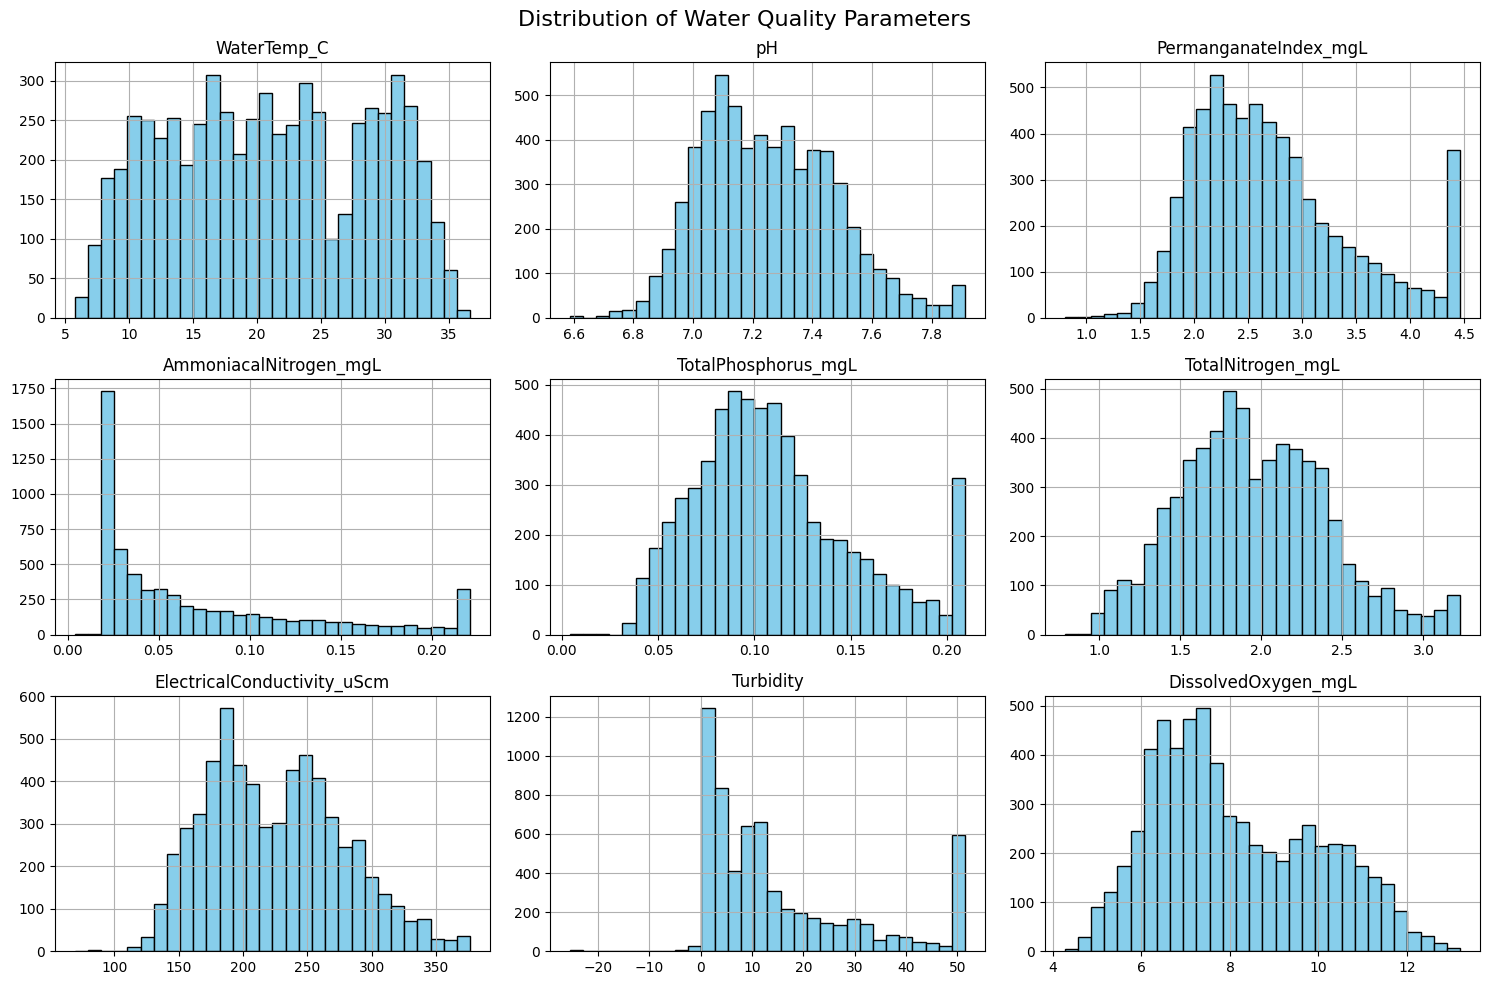

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distributions for all numerical features
numeric_cols = [col for col in odata.columns if col != 'date']
odata[numeric_cols].hist(bins=30, figsize=(15, 10), layout=(3, 3), color='skyblue', edgecolor='black')
plt.suptitle('Distribution of Water Quality Parameters', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Visualize correlations between all water-quality features as a heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = odata[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Water Quality Features', fontsize=14)
plt.show()


In [ ]:
# Scatterplots of Ammoniacal Nitrogen against three predictors linked to
# sewage / organic pollution loading
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=odata, x='PermanganateIndex_mgL', y='AmmoniacalNitrogen_mgL', ax=axes[0], alpha=0.5, color='crimson')
axes[0].set_title('NH3-N vs Permanganate Index')

sns.scatterplot(data=odata, x='TotalNitrogen_mgL', y='AmmoniacalNitrogen_mgL', ax=axes[1], alpha=0.5, color='purple')
axes[1].set_title('NH3-N vs Total Nitrogen')

sns.scatterplot(data=odata, x='Turbidity', y='AmmoniacalNitrogen_mgL', ax=axes[2], alpha=0.5, color='teal')
axes[2].set_title('NH3-N vs Turbidity')

plt.tight_layout()
plt.show()


In [ ]:
# Final check of data types and non-null counts before modeling
odata.info()


## Stage 4: Point-in-Time Model — Build & Baseline

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y) - now predicting Ammoniacal Nitrogen,
# our chosen proxy for contamination risk. DissolvedOxygen_mgL is now just
# a regular input feature.
X = odata.drop(columns=['date', 'AmmoniacalNitrogen_mgL'])
y = odata['AmmoniacalNitrogen_mgL']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


In [26]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model (100 trees is a solid baseline)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Fit the model on training data
rf_model.fit(X_train, y_train)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


In [27]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make predictions on test set
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"--- Model Performance Metrics ---")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f} mg/L")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} mg/L")

--- Model Performance Metrics ---
R² Score: 0.9512
Mean Absolute Error (MAE): 0.2829 mg/L
Root Mean Squared Error (RMSE): 0.3999 mg/L


In [ ]:
# Compare training vs. testing R² to check for overfitting, and store
# them in named variables so they can be reused later (e.g. in the CV gap check)
train_r2 = rf_model.score(X_train, y_train)
test_r2 = rf_model.score(X_test, y_test)
print("Training R²:", train_r2)
print("Testing R²:", test_r2)


In [ ]:
# Rank features by their importance in the Random Forest model
import pandas as pd

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importances
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Random Forest Feature Importance for Ammoniacal Nitrogen', fontsize=12, fontweight='bold')
plt.xlabel('Relative Importance Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score

# Perform 5-Fold Cross-Validation on training data
r2_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

# Perform 5-Fold Cross-Validation for RMSE
neg_rmse_scores = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

rmse_scores = -neg_rmse_scores

# Display stability metrics
print("--- 5-Fold Cross-Validation Stability Results ---")
print(f"R² Scores for each fold: {r2_scores}")
print(f"Mean R² Score: {r2_scores.mean():.4f} (± {r2_scores.std():.4f})")

print(f"\nRMSE Scores for each fold: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.4f} (± {rmse_scores.std():.4f}) mg/L")

mean_cv_r2 = r2_scores.mean()


## Stage 5: Diagnose & Fix Overfitting

In [ ]:
# Compare training R² vs. mean cross-validation R².
# A large gap indicates the model is overfitting to the training data.
print(f"Training R² Score: {train_r2:.4f}")
print(f"Mean CV R² Score: {mean_cv_r2:.4f}")
print(f"Gap: {train_r2 - mean_cv_r2:.4f}")


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Tuned Random Forest - settings chosen after comparing a few configs by hand
# (depth=10 underfit slightly; depth=15 gave the best CV R² / gap trade-off)
tuned_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

# Train on training data
tuned_rf.fit(X_train, y_train)

# Training R²
new_train_r2 = tuned_rf.score(X_train, y_train)

# 5-Fold Cross-Validation on training data
new_cv_scores = cross_val_score(
    tuned_rf,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

# Mean CV R²
new_cv_r2 = new_cv_scores.mean()

# Training-CV gap
new_gap = new_train_r2 - new_cv_r2

print("--- Tuned Random Forest Results ---")
print(f"New Training R² Score: {new_train_r2:.4f}")
print(f"CV R² Scores: {new_cv_scores}")
print(f"Mean CV R² Score: {new_cv_r2:.4f}")
print(f"New Gap: {new_gap:.4f}")

# Make this the model used everywhere downstream (comparison table,
# final evaluation, and the saved .pkl file) instead of the baseline.
rf_model = tuned_rf
print("\nrf_model now points to the tuned Random Forest - all cells below this point use it.")


## Stage 6: Model Comparison / Selection

In [34]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make predictions on test set
y_pred_lr = lr_model.predict(X_test)

# Calculate evaluation metrics
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"--- Linear Regression Performance Metrics ---")
print(f"R² Score: {r2_lr:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f} mg/L")
print(f"Root Mean Squared Error (RMSE): {rmse_lr:.4f} mg/L")

--- Linear Regression Performance Metrics ---
R² Score: 0.7829
Mean Absolute Error (MAE): 0.6508 mg/L
Root Mean Squared Error (RMSE): 0.8430 mg/L


In [35]:
from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree Regressor
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on test set
y_pred_dt = dt_model.predict(X_test)

import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate evaluation metrics
r2_dt = r2_score(y_test, y_pred_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))

print(f"--- Decision Tree Performance Metrics ---")
print(f"R² Score: {r2_dt:.4f}")
print(f"Mean Absolute Error (MAE): {mae_dt:.4f} mg/L")
print(f"Root Mean Squared Error (RMSE): {rmse_dt:.4f} mg/L")

--- Decision Tree Performance Metrics ---
R² Score: 0.8960
Mean Absolute Error (MAE): 0.3806 mg/L
Root Mean Squared Error (RMSE): 0.5836 mg/L


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Recompute Random Forest metrics live from whatever rf_model currently is
# (baseline or tuned), so this table can never go stale after re-running
# earlier cells in a different order.
rf_predictions = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

# Create a table comparing the performance of all three models.
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree Regressor',
        'Random Forest Regressor'
    ],

    # R²: Higher values are better
    'R² Score': [r2_lr, r2_dt, rf_r2],

    # MAE: Lower values are better
    'MAE (mg/L)': [mae_lr, mae_dt, rf_mae],

    # RMSE: Lower values are better
    'RMSE (mg/L)': [rmse_lr, rmse_dt, rf_rmse]
})

# Display the comparison table
print("--- Model Comparison ---")
print(model_comparison)


In [47]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make predictions using the selected Random Forest model
final_predictions = rf_model.predict(X_test)

# Calculate final evaluation metrics
final_r2 = r2_score(y_test, final_predictions)
final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))

print("--- Final Random Forest Model Evaluation ---")
print(f"Final R² Score: {final_r2:.4f}")
print(f"Final MAE: {final_mae:.4f} mg/L")
print(f"Final RMSE: {final_rmse:.4f} mg/L")

--- Final Random Forest Model Evaluation ---
Final R² Score: 0.9512
Final MAE: 0.2829 mg/L
Final RMSE: 0.3999 mg/L


## Stage 7: Persistence & Inference

In [ ]:
import joblib

# Save the final trained Random Forest model
joblib.dump(rf_model, 'ammoniacal_nitrogen_random_forest.pkl')

print("Final model saved successfully.")


In [ ]:
import joblib

# Load the saved Random Forest model
loaded_model = joblib.load('ammoniacal_nitrogen_random_forest.pkl')

print("Model loaded successfully.")


In [52]:
import pandas as pd

# Show the exact order of features used when training the model
print("Expected feature order:")
print(rf_model.feature_names_in_)

Expected feature order:
['WaterTemp_C' 'pH' 'PermanganateIndex_mgL' 'AmmoniacalNitrogen_mgL'
 'TotalPhosphorus_mgL' 'TotalNitrogen_mgL' 'ElectricalConductivity_uScm'
 'Turbidity']


In [ ]:
import pandas as pd

# Create new water-quality data.
# Values are keyed by column name (order doesn't matter here) - we then
# reindex to rf_model.feature_names_in_ right before predicting, so this
# cell can never break due to a column-order mismatch.
new_data = pd.DataFrame({
    'WaterTemp_C': [22.5],
    'pH': [7.2],
    'PermanganateIndex_mgL': [4.5],
    'TotalPhosphorus_mgL': [0.08],
    'TotalNitrogen_mgL': [1.2],
    'ElectricalConductivity_uScm': [450],
    'Turbidity': [3.1],
    'DissolvedOxygen_mgL': [7.8]
})

# Reorder columns to exactly match what the model was trained on
new_data = new_data[rf_model.feature_names_in_]

# Make a prediction using the final Random Forest model
prediction = rf_model.predict(new_data)

# Display the predicted Ammoniacal Nitrogen level
print(f"Predicted Ammoniacal Nitrogen: {prediction[0]:.2f} mg/L")


## Stage 8: Time-Series Forecasting Pipeline

In [54]:
# Display all column names
print(odata.columns)

# Display the first 5 rows
print(odata.head())

Index(['date', 'WaterTemp_C', 'pH', 'PermanganateIndex_mgL',
       'AmmoniacalNitrogen_mgL', 'TotalPhosphorus_mgL', 'TotalNitrogen_mgL',
       'ElectricalConductivity_uScm', 'Turbidity', 'DissolvedOxygen_mgL'],
      dtype='str')
                 date  WaterTemp_C        pH  PermanganateIndex_mgL  \
0 2021-01-01 00:00:00    10.262857  6.997429               2.002143   
1 2021-01-01 04:00:00     8.148571  7.010286               1.911429   
2 2021-01-01 08:00:00     9.677143  7.014571               2.482857   
3 2021-01-01 12:00:00    11.922857  7.022000               2.878000   
4 2021-01-01 16:00:00    13.485714  7.040857               2.863143   

   AmmoniacalNitrogen_mgL  TotalPhosphorus_mgL  TotalNitrogen_mgL  \
0                0.147800             0.149114           2.295143   
1                0.153800             0.147543           2.249429   
2                0.136800             0.146686           2.240857   
3                0.112000             0.146143           2.285143

In [ ]:
# Make a copy of the original data
forecast_data = odata.copy()

# Convert the date column to datetime
forecast_data['date'] = pd.to_datetime(forecast_data['date'])

# Sort observations chronologically
forecast_data = forecast_data.sort_values('date')

# Reset the index
forecast_data = forecast_data.reset_index(drop=True)

# Display the first few observations
print(forecast_data[['date', 'AmmoniacalNitrogen_mgL']].head())


In [56]:
# Display the first and last date
print("Start date:", forecast_data['date'].min())
print("End date:", forecast_data['date'].max())

# Check the time interval between observations
print(forecast_data['date'].diff().value_counts().head())

Start date: 2021-01-01 00:00:00
End date: 2024-04-30 08:00:00
date
0 days 04:00:00    5730
0 days 08:00:00     387
0 days 12:00:00      39
0 days 20:00:00      14
0 days 16:00:00      14
Name: count, dtype: int64


In [57]:
# Make sure the date column is datetime
forecast_data['date'] = pd.to_datetime(forecast_data['date'])

# Set date as the index
forecast_data = forecast_data.set_index('date')

# Resample to a regular 4-hour interval
forecast_data = forecast_data.resample('4h').mean()

# Interpolate missing values
forecast_data = forecast_data.interpolate(method='time')

# Reset the index
forecast_data = forecast_data.reset_index()

# Check the time intervals again
print(forecast_data['date'].diff().value_counts().head())

date
0 days 04:00:00    7292
Name: count, dtype: int64


In [ ]:
# Create lag features for forecasting ammoniacal nitrogen

# Ammoniacal Nitrogen from 4 hours ago
forecast_data['NH3_lag_1'] = forecast_data['AmmoniacalNitrogen_mgL'].shift(1)

# Ammoniacal Nitrogen from 8 hours ago
forecast_data['NH3_lag_2'] = forecast_data['AmmoniacalNitrogen_mgL'].shift(2)

# Ammoniacal Nitrogen from 12 hours ago
forecast_data['NH3_lag_3'] = forecast_data['AmmoniacalNitrogen_mgL'].shift(3)

# Ammoniacal Nitrogen from 24 hours ago
forecast_data['NH3_lag_6'] = forecast_data['AmmoniacalNitrogen_mgL'].shift(6)

# Display the first 10 rows
print(
    forecast_data[
        ['date',
         'AmmoniacalNitrogen_mgL',
         'NH3_lag_1',
         'NH3_lag_2',
         'NH3_lag_3',
         'NH3_lag_6']
    ].head(10)
)


In [ ]:
# Remove rows with missing lag values
forecast_data = forecast_data.dropna(
    subset=['NH3_lag_1', 'NH3_lag_2', 'NH3_lag_3', 'NH3_lag_6']
).reset_index(drop=True)

# Check the resulting dataset
print("Number of observations:", len(forecast_data))
print(forecast_data.head())


In [ ]:
# Define the forecasting features.
# DissolvedOxygen_mgL is now a regular predictor; the lag features are
# built from the new target, Ammoniacal Nitrogen.
forecast_features = [
    'WaterTemp_C',
    'pH',
    'PermanganateIndex_mgL',
    'TotalPhosphorus_mgL',
    'TotalNitrogen_mgL',
    'ElectricalConductivity_uScm',
    'Turbidity',
    'DissolvedOxygen_mgL',
    'NH3_lag_1',
    'NH3_lag_2',
    'NH3_lag_3',
    'NH3_lag_6'
]

# Create X (input features)
X_forecast = forecast_data[forecast_features]

# Create y (target)
y_forecast = forecast_data['AmmoniacalNitrogen_mgL']

# Check the shapes
print("X shape:", X_forecast.shape)
print("y shape:", y_forecast.shape)


In [61]:
# Determine the split point: 80% training, 20% testing
split_index = int(len(forecast_data) * 0.8)

# Split the features chronologically
X_forecast_train = X_forecast.iloc[:split_index]
X_forecast_test = X_forecast.iloc[split_index:]

# Split the target chronologically
y_forecast_train = y_forecast.iloc[:split_index]
y_forecast_test = y_forecast.iloc[split_index:]

# Display the number of observations
print("Training observations:", len(X_forecast_train))
print("Testing observations:", len(X_forecast_test))

# Display the time periods
print("\nTraining period:")
print(
    forecast_data['date'].iloc[0],
    "to",
    forecast_data['date'].iloc[split_index - 1]
)

print("\nTesting period:")
print(
    forecast_data['date'].iloc[split_index],
    "to",
    forecast_data['date'].iloc[-1]
)

Training observations: 5829
Testing observations: 1458

Training period:
2021-01-02 00:00:00 to 2023-08-31 08:00:00

Testing period:
2023-08-31 12:00:00 to 2024-04-30 08:00:00


In [62]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest forecasting model
forecast_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model using only the historical training data
forecast_rf.fit(
    X_forecast_train,
    y_forecast_train
)

print("Forecasting Random Forest trained successfully.")

Forecasting Random Forest trained successfully.


In [ ]:
# Make predictions on the future test data
forecast_predictions = forecast_rf.predict(X_forecast_test)

# Display the first 10 predictions alongside the actual values
print("--- Forecasting Results ---")

for actual, predicted in zip(
    y_forecast_test.iloc[:10],
    forecast_predictions[:10]
):
    print(
        f"Actual NH3-N: {actual:.4f} mg/L | "
        f"Predicted NH3-N: {predicted:.4f} mg/L"
    )


In [64]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate forecasting evaluation metrics
forecast_r2 = r2_score(y_forecast_test, forecast_predictions)
forecast_mae = mean_absolute_error(y_forecast_test, forecast_predictions)
forecast_rmse = np.sqrt(
    mean_squared_error(y_forecast_test, forecast_predictions)
)

# Display the results
print("--- Forecasting Random Forest Performance ---")
print(f"R² Score: {forecast_r2:.4f}")
print(f"MAE: {forecast_mae:.4f} mg/L")
print(f"RMSE: {forecast_rmse:.4f} mg/L")

--- Forecasting Random Forest Performance ---
R² Score: 0.9495
MAE: 0.2964 mg/L
RMSE: 0.3931 mg/L


In [ ]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(14, 6))

# Plot actual ammoniacal nitrogen values
plt.plot(
    forecast_data['date'].iloc[split_index:],
    y_forecast_test.values,
    label='Actual Ammoniacal Nitrogen'
)

# Plot predicted ammoniacal nitrogen values
plt.plot(
    forecast_data['date'].iloc[split_index:],
    forecast_predictions,
    label='Predicted Ammoniacal Nitrogen'
)

# Add axis labels
plt.xlabel('Date')
plt.ylabel('Ammoniacal Nitrogen (mg/L)')

# Add a title
plt.title('Actual vs Predicted Ammoniacal Nitrogen - Forecasting Test Period')

# Display the legend
plt.legend()

# Rotate date labels for readability
plt.xticks(rotation=45)

# Adjust the layout
plt.tight_layout()

# Display the plot
plt.show()


In [70]:
# Calculate forecasting errors
forecast_errors = y_forecast_test - forecast_predictions

print(forecast_errors.head())

5829    0.424851
5830    0.364341
5831    0.283709
5832    0.083845
5833    0.125737
Name: DissolvedOxygen_mgL, dtype: float64


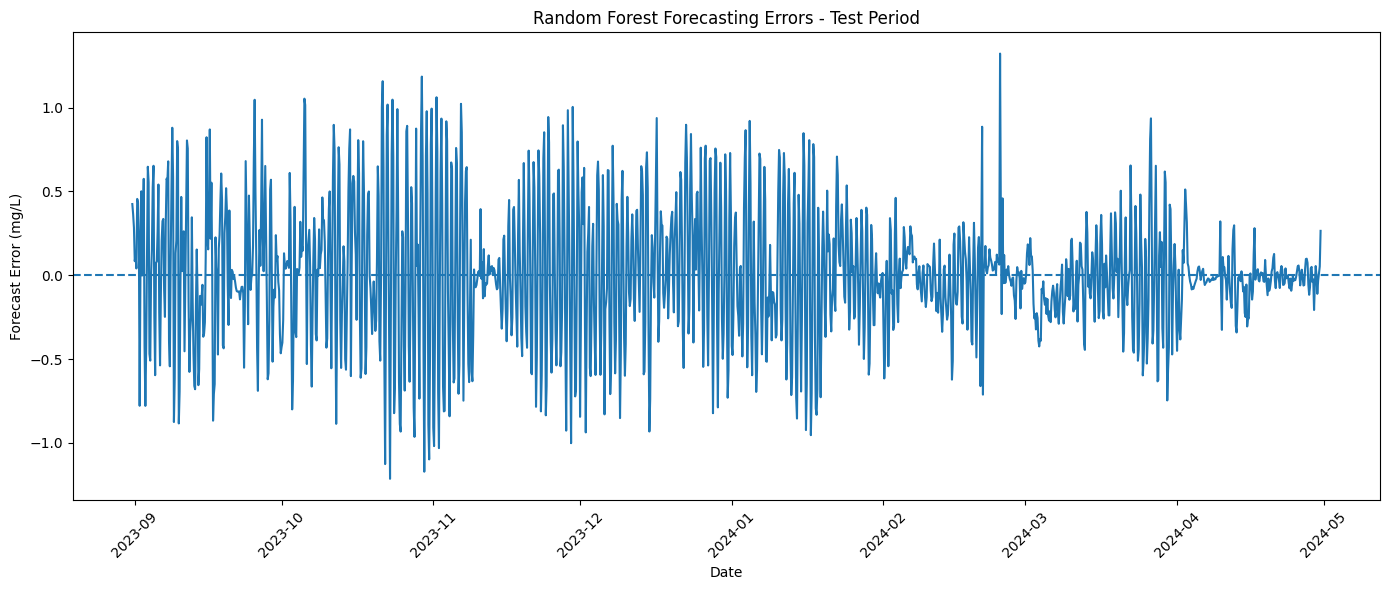

In [73]:
import matplotlib.pyplot as plt

# Calculate forecasting errors
forecast_errors = y_forecast_test.values - forecast_predictions

# Create the plot
plt.figure(figsize=(14, 6))

# Plot forecasting errors
plt.plot(
    forecast_data['date'].iloc[split_index:],
    forecast_errors
)

# Add zero reference line
plt.axhline(y=0, linestyle='--')

# Add axis labels
plt.xlabel('Date')
plt.ylabel('Forecast Error (mg/L)')

# Add title
plt.title('Random Forest Forecasting Errors - Test Period')

# Rotate date labels
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

## Stage 9: Trend & Seasonality Analysis (2021–2024)

In [ ]:
import matplotlib.pyplot as plt

# Make a copy so we don't modify the original forecasting dataset
trend_data = forecast_data.copy()

# Extract the year from the date
trend_data['year'] = trend_data['date'].dt.year

# Calculate average ammoniacal nitrogen for each year
yearly_nh3 = trend_data.groupby('year')['AmmoniacalNitrogen_mgL'].mean()

# Plot yearly average ammoniacal nitrogen
plt.figure(figsize=(14, 6))

plt.plot(
    yearly_nh3.index,
    yearly_nh3.values,
    marker='o',
    label='Average Ammoniacal Nitrogen'
)

plt.xlabel('Year')
plt.ylabel('Average Ammoniacal Nitrogen (mg/L)')
plt.title('Long-Term Trend of Average Ammoniacal Nitrogen (2021–2024)')
plt.grid(True)
plt.legend()

plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Make a copy so we don't modify the original dataset
seasonal_data = forecast_data.copy()

# Extract month number and month name
seasonal_data['month'] = seasonal_data['date'].dt.month

# Calculate average ammoniacal nitrogen for each month
monthly_nh3 = seasonal_data.groupby('month')['AmmoniacalNitrogen_mgL'].mean()

# Plot monthly average ammoniacal nitrogen
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_nh3.index,
    monthly_nh3.values,
    marker='o',
    label='Average Ammoniacal Nitrogen'
)

plt.xlabel('Month')
plt.ylabel('Average Ammoniacal Nitrogen (mg/L)')
plt.title('Seasonal Pattern of Average Ammoniacal Nitrogen')
plt.xticks(
    range(1, 13),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)

plt.grid(True)
plt.legend()

plt.show()


In [ ]:
# Trend and Seasonality Conclusion (Ammoniacal Nitrogen)
print("""
Trend and Seasonality Conclusion (Ammoniacal Nitrogen):

Yearly trend (2021-2024): No consistent long-term direction - values rise,
drop sharply, then rise again. With only 4 years of data, this looks more
like short-term variability than a real trend.

Seasonal pattern (monthly): Clear and consistent. Ammonia peaks in winter
(Jan-Feb, ~0.13-0.14 mg/L) and drops to its lowest in late summer
(Aug-Sep, ~0.04 mg/L) - about a threefold difference. This fits known
water chemistry: nitrification (ammonia → nitrate) is temperature-driven
and slows in cold water, letting ammonia build up in winter.

Overall: Ammoniacal Nitrogen is seasonally driven, not trending - similar
to the original DO analysis, but through a different mechanism
(nitrification rate vs. oxygen solubility).
""")
